In [1]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

ЭТАП 1: Анализ данных (EDA)

Общая загрузка

In [2]:
# 1 Загрузить CSV и вывести первые 10 строк.
df = pd.read_csv('loan_data.csv')
df.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [3]:
# 2 Посмотреть .info() и .shape.
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

(45000, 14)

In [4]:
# 3 Проверить уникальные значения по object-признакам.
unique_home_ownership = df['person_home_ownership'].unique()
print("Уникальные значения для person_home_ownership:", unique_home_ownership)

Уникальные значения для person_home_ownership: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']


In [5]:
# 4 Оставить только выбранные 7 признаков + целевую переменную.
selected_columns = ['person_age', 'person_income', 'person_emp_exp', 'person_home_ownership',
                    'loan_amnt', 'loan_int_rate', 'credit_score', 'loan_status']
df = df[selected_columns]
print("Оставленные столбцы:", df.columns.tolist())

Оставленные столбцы: ['person_age', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_int_rate', 'credit_score', 'loan_status']


In [6]:
# 5 Сохранить облегчённый датасет в loan_clean.csv.
df.to_csv('loan_clean.csv', index=False)

In [7]:
# 6 Посчитать средний доход, возраст, стаж.
income = round(df['person_income'].mean(), 2)
age = round(df['person_age'].mean(), 2)
exp = round(df['person_emp_exp'].mean(), 2)
print(f'Средний доход: {income}, Средний возраст: {age}, Средний стаж: {exp}')

Средний доход: 80319.05, Средний возраст: 27.76, Средний стаж: 5.41


In [8]:
# 7 Сколько заемщиков имеют кредитный балл < 600?
credit_score = (df['credit_score'] < 600).sum()
print(f'{credit_score} заемщиков имеют кредитный балл < 600.')

10828 заемщиков имеют кредитный балл < 600.


In [9]:
# 8 Распределение по типу жилья (person_home_ownership) — value_counts().
print(df['person_home_ownership'].value_counts())

person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64


In [10]:
# 9 Средняя ставка и сумма кредита по группам loan_status.
print(df.groupby('loan_status')[['loan_int_rate', 'loan_amnt']].mean().round())

             loan_int_rate  loan_amnt
loan_status                          
0                     10.0     9220.0
1                     13.0    10856.0


In [11]:
# 10 Кол-во заявителей с опытом работы 0 лет.
print('Кол-во заявителей с опытом работы 0 лет:', (df['person_emp_exp'] == 0).sum())

Кол-во заявителей с опытом работы 0 лет: 9566


In [12]:
# 12 Группировка по person_home_ownership — средний loan_int_rate.
print((df.groupby('person_home_ownership')['loan_int_rate']).mean().round(2))

person_home_ownership
MORTGAGE    10.56
OTHER       12.03
OWN         10.83
RENT        11.38
Name: loan_int_rate, dtype: float64


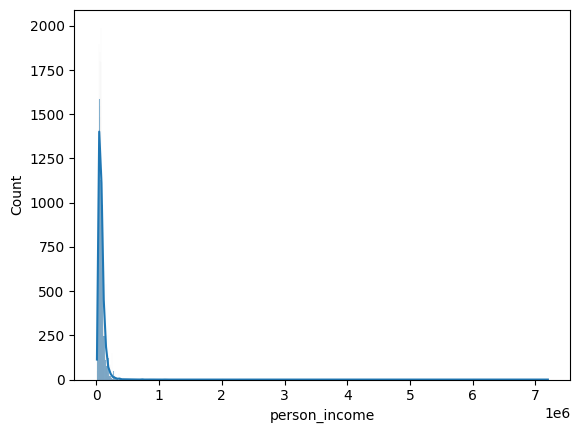

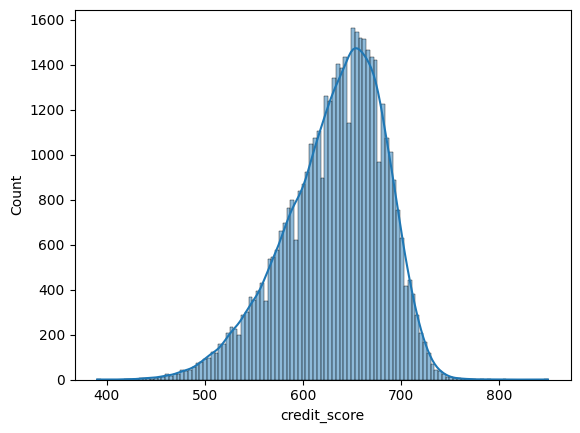

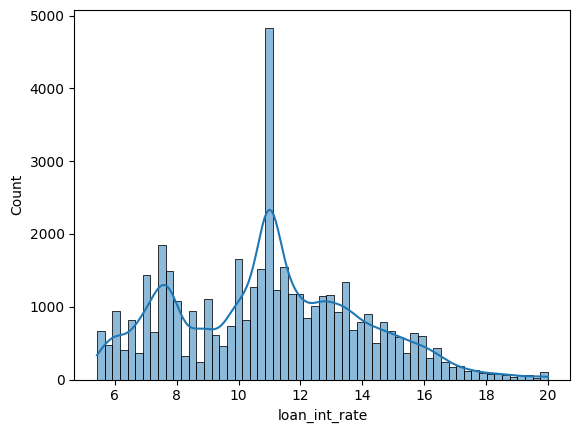

In [13]:
# 13 Hist / distplot по:
    # person_income
    # credit_score
    # loan_int_rate

sns.histplot(df['person_income'], kde=True)
plt.show()
sns.histplot(df['credit_score'], kde=True)
plt.show()
sns.histplot(df['loan_int_rate'], kde=True)
plt.show()

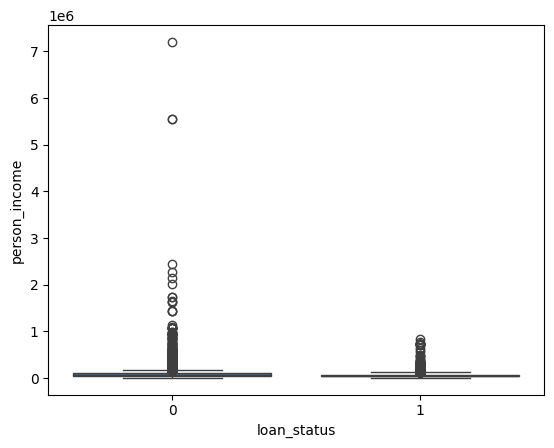

In [14]:
# 14 Boxplot: loan_status vs person_income
sns.boxplot(x='loan_status', y='person_income', data=df)
plt.show()

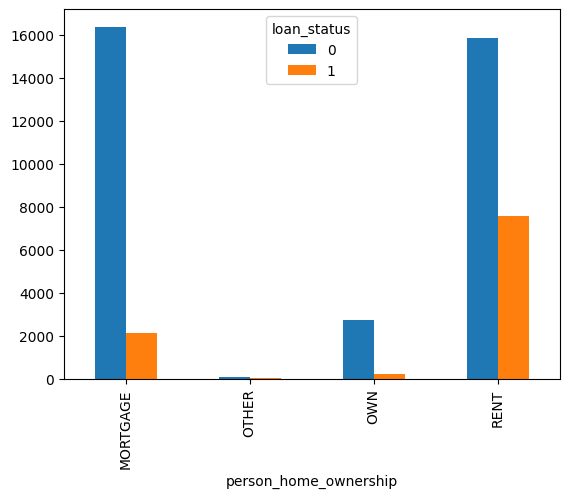

In [15]:
# 15 Barplot: loan_status vs person_home_ownership

plot_data = df.groupby(['person_home_ownership', 'loan_status']).size().unstack()
plot_data.plot(kind='bar', stacked=False)
plt.show()

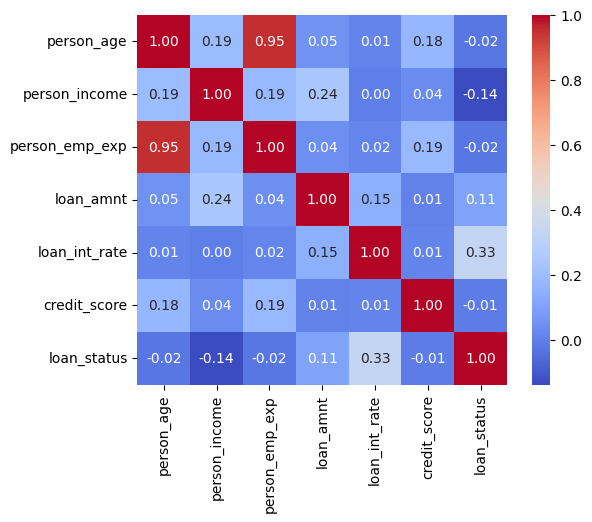

In [16]:
# 16 Heatmap корреляций числовых признаков

numeric_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'credit_score', 'loan_status']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.show()

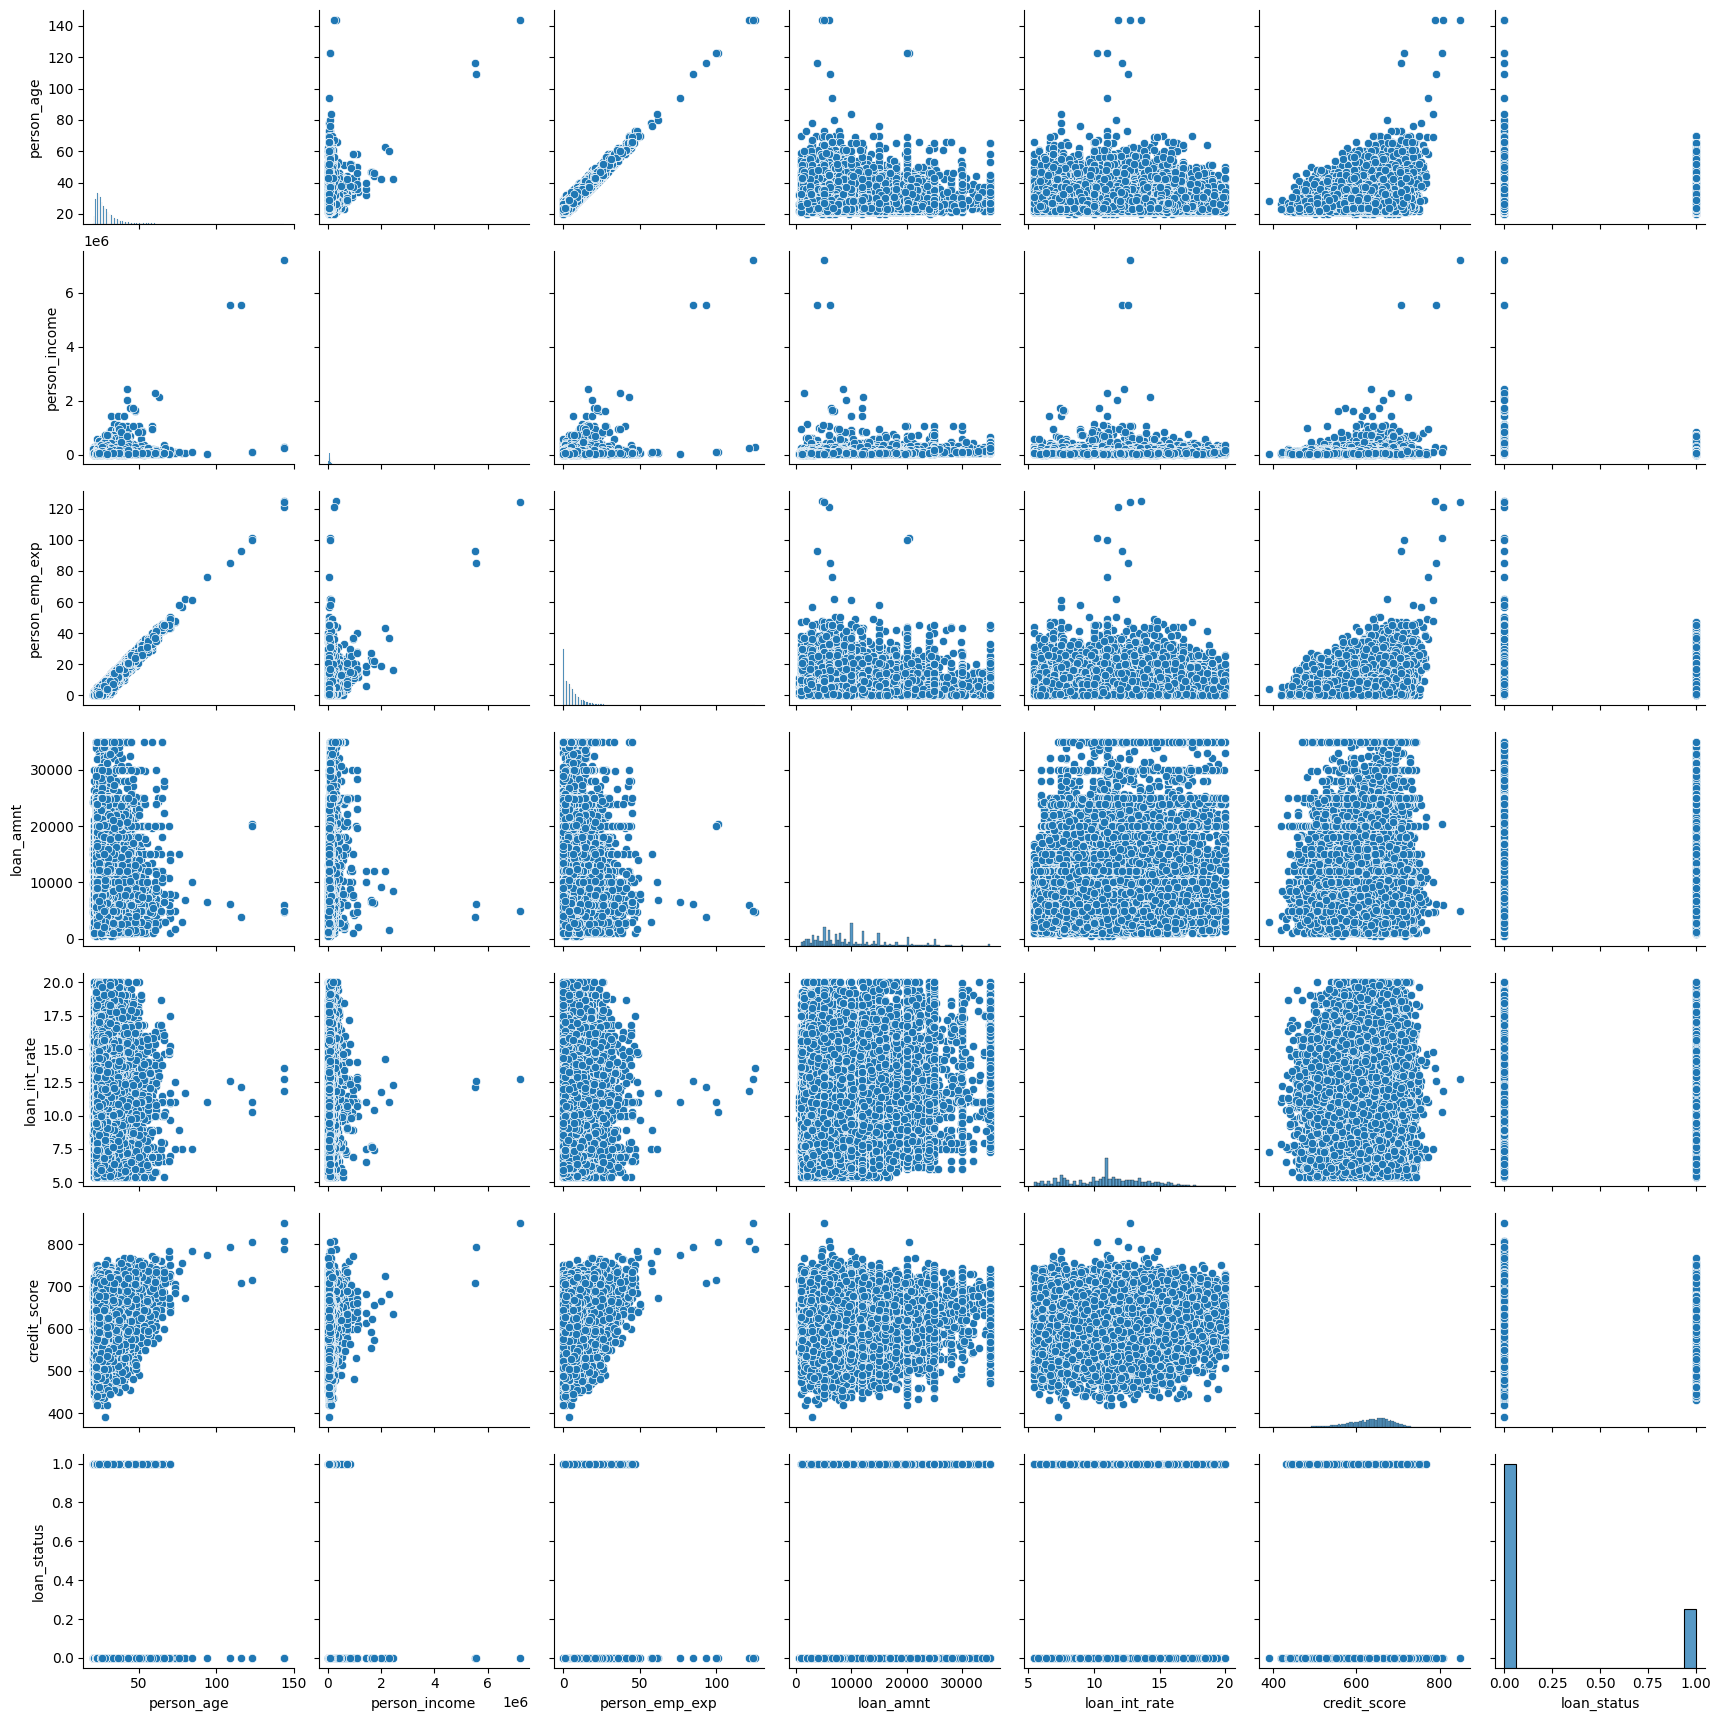

In [17]:
# 17 Pairplot по числовым признакам

numeric_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'credit_score', 'loan_status']
sns.pairplot(df[numeric_cols])
plt.show()

ЭТАП 2: Предобработка

In [18]:
# 18 Проверка пропущенных значений и заполнение (или удаление).
df.isnull().sum()

,0
person_age,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_int_rate,0
credit_score,0
loan_status,0


In [19]:
# Сплит до масштабирования (исправление утечки)
x = df.drop(columns=['loan_status'])
y = df['loan_status']

In [20]:
# 19 Кодировка категориальных признаков (OneHotEncoder или LabelEncoder):
    # person_home_ownership
x = pd.get_dummies(x, columns=['person_home_ownership'], drop_first=True)

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [22]:
# 20 Масштабирование числовых признаков (StandardScaler).
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [23]:
x_train

array([[ 1.03947529,  0.19422493,  0.93118562, ..., -0.0525127 ,
        -0.26600629, -1.0412385 ],
       [-0.4561859 , -0.089962  , -0.39501412, ..., -0.0525127 ,
        -0.26600629,  0.96039476],
       [ 2.20276733,  2.82816736,  2.0916104 , ..., -0.0525127 ,
        -0.26600629, -1.0412385 ],
       ...,
       [ 0.87329072, -0.26104458,  0.59963569, ..., -0.0525127 ,
        -0.26600629, -1.0412385 ],
       [-0.29000132,  1.14498636,  0.10231078, ..., -0.0525127 ,
        -0.26600629,  0.96039476],
       [-0.29000132,  1.52245281, -0.22923915, ..., -0.0525127 ,
        -0.26600629, -1.0412385 ]])

ЭТАП 3: регрессия

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [25]:
# 23 Обучить LogisticRegression() на обучающей выборке.
model_log = LogisticRegression()
model_tree = DecisionTreeClassifier()
model_rf = RandomForestClassifier()

In [26]:
model_log.fit(x_train, y_train)

LogisticRegression()

In [27]:
model_tree.fit(x_train, y_train)

DecisionTreeClassifier()

In [28]:
model_rf.fit(x_train, y_train)

RandomForestClassifier()

In [29]:
# 24 Предсказать на тестовой выборке.
y_predict_lg = model_log.predict(x_test)
y_predict_tree = model_tree.predict(x_test)
y_predict_rf = model_rf.predict(x_test)

In [30]:
# 25 Посчитать метрики:
    # Accuracy
    # Precision, Recall
    # F1-score
    # Confusion Matrix (график)
    # ROC AUC (и построить кривую)
print(f'Model log: {accuracy_score(y_test, y_predict_lg)}')
print(f'Model tree: {accuracy_score(y_test, y_predict_tree)}')
print(f'Model rf: {accuracy_score(y_test, y_predict_rf)}')

Model log: 0.829
Model tree: 0.8478888888888889
Model rf: 0.8906666666666667


In [31]:
print('accuracy_score:')
print(f'Model Log: {accuracy_score(y_test, y_predict_lg)}')
print(f'Model Tree: {accuracy_score(y_test, y_predict_tree)}')
print(f'Model Rf: {accuracy_score(y_test, y_predict_rf)}')

accuracy_score:
Model Log: 0.829
Model Tree: 0.8478888888888889
Model Rf: 0.8906666666666667


In [32]:
print('precision_score:')
print(f'Model Log Precision: {precision_score(y_test, y_predict_lg, average="weighted")}')
print(f'Model Log Recall: {recall_score(y_test, y_predict_lg, average="weighted")}')
print(f'Model Log F1: {f1_score(y_test, y_predict_lg, average="weighted")}')

precision_score:
Model Log Precision: 0.8153969277000851
Model Log Recall: 0.829
Model Log F1: 0.8106568601535248


In [33]:
print('recall_score:')
print(f'Model Tree Precision: {precision_score(y_test, y_predict_tree, average="weighted")}')
print(f'Model Tree Recall: {recall_score(y_test, y_predict_tree, average="weighted")}')
print(f'Model Tree F1: {f1_score(y_test, y_predict_tree, average="weighted")}')

recall_score:
Model Tree Precision: 0.8477544796574207
Model Tree Recall: 0.8478888888888889
Model Tree F1: 0.8478213664554607


In [34]:
print('f1_score:')
print(f'Model RF Precision: {precision_score(y_test, y_predict_rf, average="weighted")}')
print(f'Model RF Recall: {recall_score(y_test, y_predict_rf, average="weighted")}')
print(f'Model RF F1: {f1_score(y_test, y_predict_rf, average="weighted")}')

f1_score:
Model RF Precision: 0.8873573333333333
Model RF Recall: 0.8906666666666667
Model RF F1: 0.8846477322999061


In [35]:
print('classification_report:')
print(f'Model Log: {classification_report(y_test, y_predict_lg)}')
print(f'Model Tree: {classification_report(y_test, y_predict_tree)}')
print(f'Model Rf: {classification_report(y_test, y_predict_rf)}')

classification_report:
Model Log:               precision    recall  f1-score   support

           0       0.85      0.95      0.90      6990
           1       0.70      0.40      0.51      2010

    accuracy                           0.83      9000
   macro avg       0.78      0.68      0.70      9000
weighted avg       0.82      0.83      0.81      9000

Model Tree:               precision    recall  f1-score   support

           0       0.90      0.90      0.90      6990
           1       0.66      0.66      0.66      2010

    accuracy                           0.85      9000
   macro avg       0.78      0.78      0.78      9000
weighted avg       0.85      0.85      0.85      9000

Model Rf:               precision    recall  f1-score   support

           0       0.90      0.97      0.93      6990
           1       0.84      0.63      0.72      2010

    accuracy                           0.89      9000
   macro avg       0.87      0.80      0.83      9000
weighted avg      

In [40]:
# 27 Сохранить модель (joblib или pickle).
joblib.dump(model_rf, 'model_rf_CreditLoanData.pkl')
joblib.dump(scaler, 'scaler_CreditLoanData.pkl')

['scaler_CreditLoanData.pkl']

In [39]:
df.columns.tolist()

['person_age',
 'person_income',
 'person_emp_exp',
 'person_home_ownership',
 'loan_amnt',
 'loan_int_rate',
 'credit_score',
 'loan_status']